In [18]:
import numpy as np
import matplotlib.pyplot as plt
from model_ranking.utils import (
    load_h5,
    get_roi_slice
)

In [3]:
E_gt_path = "/scratch/talks/data/EPFL/test.h5"
E_gt = load_h5(E_gt_path, "labels")
E_raw = load_h5(E_gt_path, "raw")

In [10]:
path_HtoE_Resunet = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/consistency/P_full/Hm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
HtoE_pred = load_h5(path_HtoE_Resunet, "predictions")
patch_positions = load_h5(path_HtoE_Resunet, "patch_index")
f1_scores = load_h5(path_HtoE_Resunet, "hard_f1")

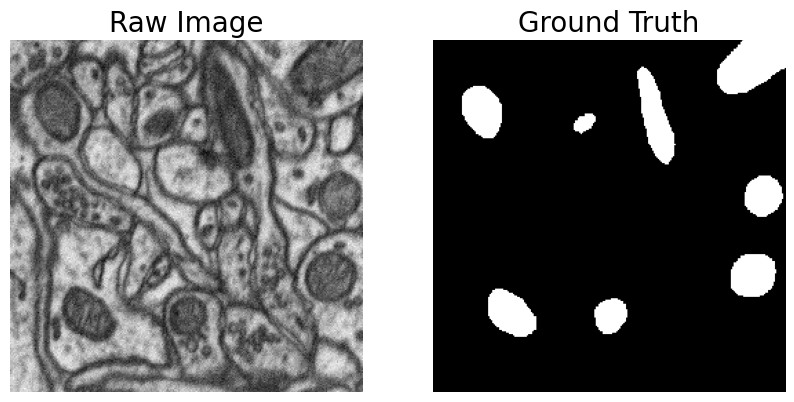

In [81]:
font_size = 20
for i, idx in enumerate(ids[9:10]):
    _ , axs = plt.subplots(1, 2, figsize=(10, 5))
    patch_slice = get_roi_slice(patch_positions[idx])
    axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    axs[0].set_title(f"Raw Image", fontsize=font_size)
    axs[0].axis('off')
    axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    axs[1].set_title(f"Ground Truth", fontsize=font_size)
    axs[1].axis('off')

In [13]:
f1_scores[:, 1].max()

0.9735542

In [20]:
HtoE_pred.shape

(750, 1, 1, 256, 256)

In [33]:
ids = np.where((f1_scores[:, 1] >= 0.85) & (f1_scores[:, 1] < 0.84))[0]
print(len(ids))

28


In [39]:
ids[10]

433

0.83478


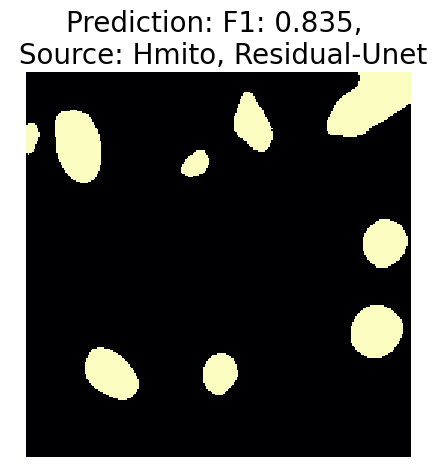

In [75]:

font_size = 20
for i, idx in enumerate(ids[9:10]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    print(f1_scores[idx, 1])
    patch_slice = get_roi_slice(patch_positions[idx])
    z, y, x = patch_positions[idx]
    # axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    # axs[0].set_title(f"Raw Image", fontsize=font_size)
    # axs[0].axis('off')
    # axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    # axs[1].set_title(f"Ground Truth", fontsize=font_size)
    # axs[1].axis('off')
    axs.imshow(HtoE_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs.set_title(f"Prediction: F1: {f1_scores[idx, 1]:.3f}, \n Source: Hmito, Residual-Unet", fontsize=font_size)
    axs.axis('off')
plt.show()

In [36]:
RtoE_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_NA2/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_pred = load_h5(RtoE_path, "predictions")
RtoE_patch_positions = load_h5(RtoE_path, "patch_index")
RtoE_f1_scores = load_h5(RtoE_path, "hard_f1")


In [38]:
RtoE_f1_scores[:, 1].mean()

0.090473324

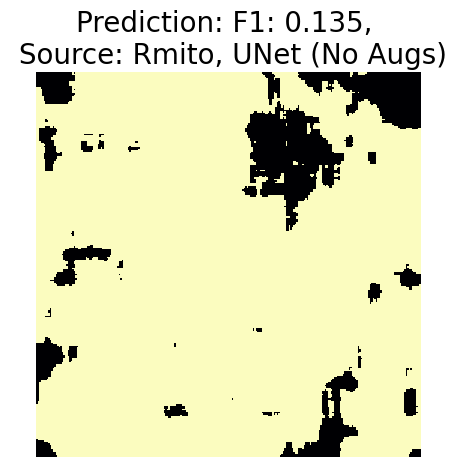

In [76]:
font_size = 20
for i, idx in enumerate(ids[9:10]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_patch_positions[idx])
    # axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    # axs[0].set_title(f"Raw Image", fontsize=font_size)
    # axs[0].axis('off')
    # axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    # axs[1].set_title(f"Ground Truth", fontsize=font_size)
    # axs[1].axis('off')
    axs.imshow(RtoE_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs.set_title(f"Prediction: F1: {RtoE_f1_scores[idx, 1]:.3f}, \n Source: Rmito, UNet (No Augs)", fontsize=font_size)
    axs.axis('off')
plt.show()

In [41]:
RtoE_Unetr_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Unetr2/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_Unetr_pred = load_h5(RtoE_Unetr_path, "predictions")
RtoE_Unetr_patch_positions = load_h5(RtoE_Unetr_path, "patch_index")
RtoE_Unetr_f1_scores = load_h5(RtoE_Unetr_path, "hard_f1")

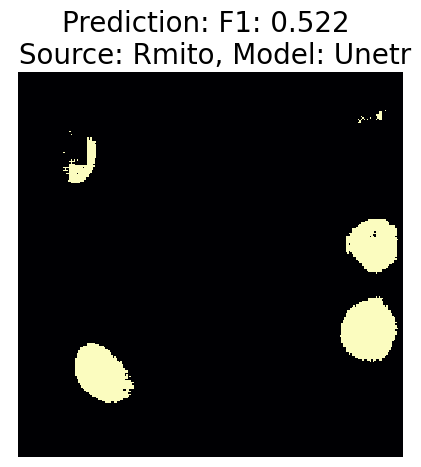

In [77]:
font_size = 20
for i, idx in enumerate(ids[9:10]):
    _ , axs = plt.subplots(1, 1, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_Unetr_patch_positions[idx])
    # axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    # axs[0].set_title(f"Raw Image", fontsize=font_size)
    # axs[0].axis('off')
    # axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    # axs[1].set_title(f"Ground Truth", fontsize=font_size)
    # axs[1].axis('off')
    axs.imshow(RtoE_Unetr_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs.set_title(f"Prediction: F1: {RtoE_Unetr_f1_scores[idx, 1]:.3f} \n Source: Rmito, Model: Unetr", fontsize=font_size)
    axs.axis('off')
plt.show()

In [53]:
Rmito_gt_path = "/scratch/talks/data/Rmito/test_converted.h5"
Rmito_gt = load_h5(Rmito_gt_path, "labels")
Rmito_raw = load_h5(Rmito_gt_path, "raw")

In [54]:
Rmito_raw.shape

(150, 4096, 4096)

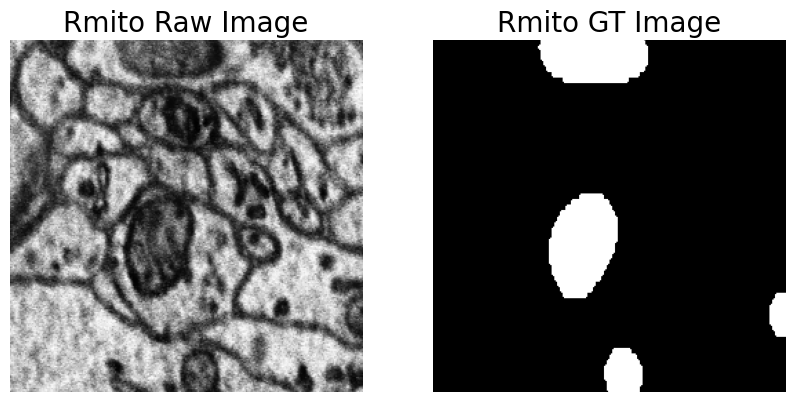

In [71]:
_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(Rmito_raw[0, 500:756, 500:756], cmap="gray")
axs[0].axis('off')
axs[0].set_title("Rmito Raw Image", fontsize=font_size)

axs[1].imshow(Rmito_gt[0, 500:756, 500:756], cmap="gray")
axs[1].axis('off')
axs[1].set_title("Rmito GT Image", fontsize=font_size)

plt.show()

In [58]:
Hmito_gt_path = "/scratch/talks/data/Hmito/test_converted.h5"
Hmito_gt = load_h5(Hmito_gt_path, "labels")
Hmito_raw = load_h5(Hmito_gt_path, "raw")

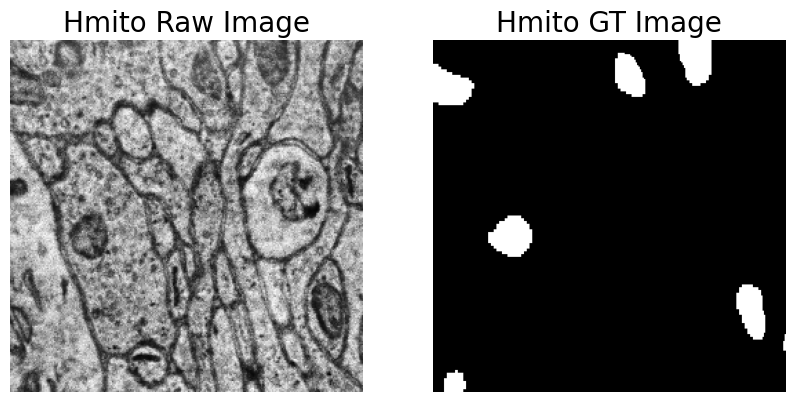

In [70]:

_, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(Hmito_raw[0, 500:756, 500:756], cmap="gray")
axs[0].axis('off')
axs[0].set_title("Hmito Raw Image", fontsize=font_size)

axs[1].imshow(Hmito_gt[0, 500:756, 500:756], cmap="gray")
axs[1].axis('off')
axs[1].set_title("Hmito GT Image", fontsize=font_size)
plt.show()